# Classifying ASD and TD using the ABIDE dataset and Functional Connectivity

In [3]:
import warnings
warnings.filterwarnings('ignore')

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker, NiftiMapsMasker
from nilearn.connectome import ConnectivityMeasure

from sklearn.svm import SVC
from sklearn.linear_model import RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, validation_curve, permutation_test_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import metrics

print("Libraries imported successfully.")

Libraries imported successfully.


# Fetch ABIDE Time Series Defined by AAL

In [4]:
with open("Young_IDs", "rb") as fp:
    sub_lst = pickle.load(fp)

len(sub_lst)

752

In [5]:
abide = datasets.fetch_abide_pcp(
    data_dir = "./ABIDE",
    derivatives = ['rois_aal'],
    quality_checked = True,
    pipeline = 'cpac',
    SUB_ID = sub_lst
)

[fetch_abide_pcp] Dataset found in ABIDE/ABIDE_pcp


In [6]:
pheno = abide.phenotypic
time_series = abide.rois_aal

print(pheno.shape)
print(len(time_series))

(752, 106)
752


In [7]:
time_series[0].shape

(196, 116)

# Feature Construction -- FC

In [8]:
# Correlation measures for all subjects
conn_m = ConnectivityMeasure(
    kind = 'correlation',
    vectorize = True,
    discard_diagonal = True
)

X_conn = conn_m.fit_transform(time_series)

In [9]:
X_conn.shape

(752, 6670)

Text(0.5, 1.0, 'ROI Connectivity across Subjects')

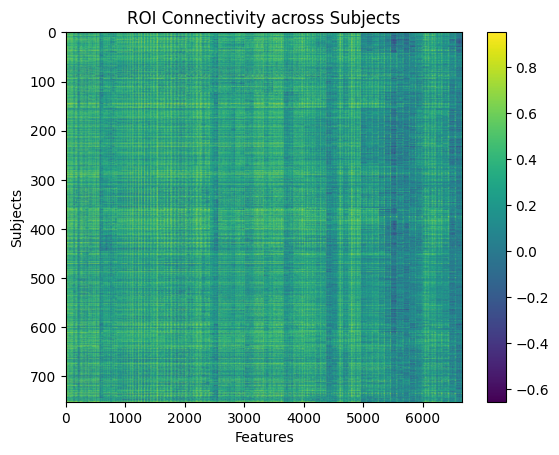

In [10]:
plt.imshow(
    X_conn,
    aspect = 'auto'
)
plt.colorbar()
plt.xlabel('Features')
plt.ylabel('Subjects')
plt.title('ROI Connectivity across Subjects')

# Dataset Prep

In [11]:
# 1 = ASD, 2 = TD
# turn TD label to 0

y_asd = np.array(pheno['DX_GROUP'].apply(lambda x: 0 if x == 2 else 1))

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_conn,
    y_asd,
    test_size = 0.2,
    stratify = y_asd,
    shuffle = True,
    random_state = 42
)

In [13]:
# Feature standardization
scl = StandardScaler()
X_train_scl = scl.fit_transform(X_train)
X_test_scl = scl.transform(X_test)

# SVC

In [91]:
svc = SVC(
    kernel = 'linear',
    class_weight = 'balanced',
    random_state = 42
)

In [35]:
# CV to choose C
C_range = 10. ** np.arange(-3, 8)

train_scores, valid_scores = validation_curve(svc, X_train_scl, y_train, 
                                              param_name= "C",
                                              param_range = C_range,
                                              cv=5,
                                              scoring='r2')

In [36]:
valid_scores

array([[-0.86153846, -0.37622378, -0.10769231, -0.24195804, -0.43973214],
       [-0.66208791, -0.51048951, -0.17482517, -0.20839161, -0.43973214],
       [-0.66208791, -0.51048951, -0.17482517, -0.20839161, -0.43973214],
       [-0.66208791, -0.51048951, -0.17482517, -0.20839161, -0.43973214],
       [-0.66208791, -0.51048951, -0.17482517, -0.20839161, -0.43973214],
       [-0.66208791, -0.51048951, -0.17482517, -0.20839161, -0.43973214],
       [-0.66208791, -0.51048951, -0.17482517, -0.20839161, -0.43973214],
       [-0.66208791, -0.51048951, -0.17482517, -0.20839161, -0.43973214],
       [-0.66208791, -0.51048951, -0.17482517, -0.20839161, -0.43973214],
       [-0.66208791, -0.51048951, -0.17482517, -0.20839161, -0.43973214],
       [-0.66208791, -0.51048951, -0.17482517, -0.20839161, -0.43973214]])

In [37]:
tScores = pd.DataFrame(train_scores).stack().reset_index()
tScores.columns = ['C','Fold','Score']
tScores.loc[:,'Type'] = ['Train' for x in range(len(tScores))]

vScores = pd.DataFrame(valid_scores).stack().reset_index()
vScores.columns = ['C','Fold','Score']
vScores.loc[:,'Type'] = ['Validate' for x in range(len(vScores))]

ValCurves = pd.concat([tScores,vScores]).reset_index(drop=True)
ValCurves.head()

,C,Fold,Score,Type
0,0,0,0.991614,Train
1,0,1,0.974903,Train
2,0,2,0.983269,Train
3,0,3,0.991634,Train
4,0,4,0.991629,Train


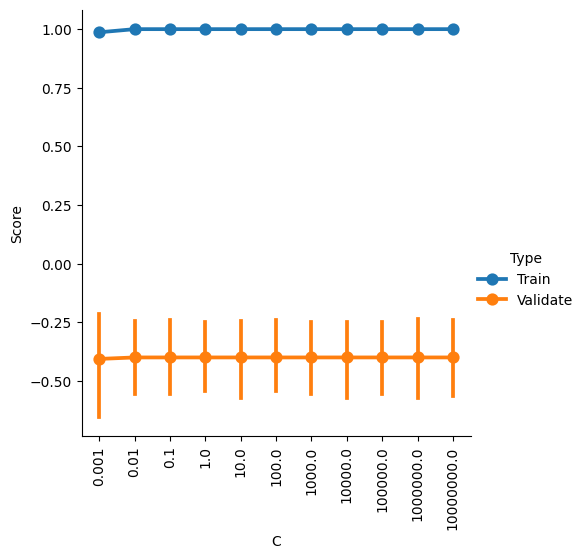

In [38]:
g = sns.catplot(x='C',y='Score',hue='Type',data=ValCurves,kind='point')
plt.xticks(range(11))
g.set_xticklabels(C_range, rotation=90)

In [39]:
y_cv = cross_val_predict(svc, X_train_scl, y_train, cv = 5)

print(classification_report(y_train, y_cv))

              precision    recall  f1-score   support

           0       0.68      0.67      0.68       324
           1       0.62      0.63      0.62       277

    accuracy                           0.65       601
   macro avg       0.65      0.65      0.65       601
weighted avg       0.65      0.65      0.65       601



In [92]:
svc_final = svc.fit(X_train_scl, y_train)
y_pred = svc_final.predict(X_test_scl)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.66      0.64        82
           1       0.57      0.54      0.55        69

    accuracy                           0.60       151
   macro avg       0.60      0.60      0.60       151
weighted avg       0.60      0.60      0.60       151



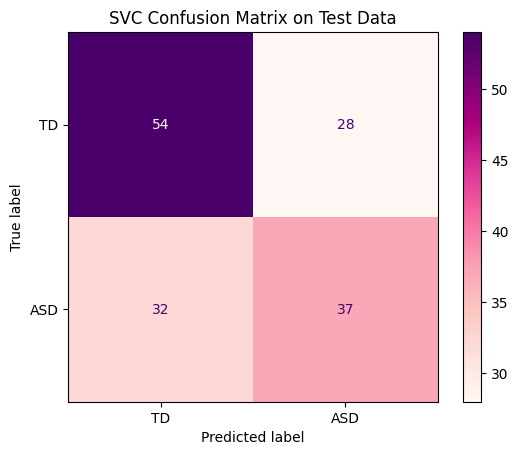

In [93]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels = [0, 1],
    display_labels = ['TD', 'ASD'],
    cmap = 'RdPu'
)

plt.title('SVC Confusion Matrix on Test Data')
plt.savefig("./Results/SVC_cm")

In [71]:
score, perm_score, pvalue = permutation_test_score(
    svc,
    X_train_scl,
    y_train,
    cv = 5,
    n_permutations = 100,
    random_state = 42,
    scoring = 'f1_macro'
)

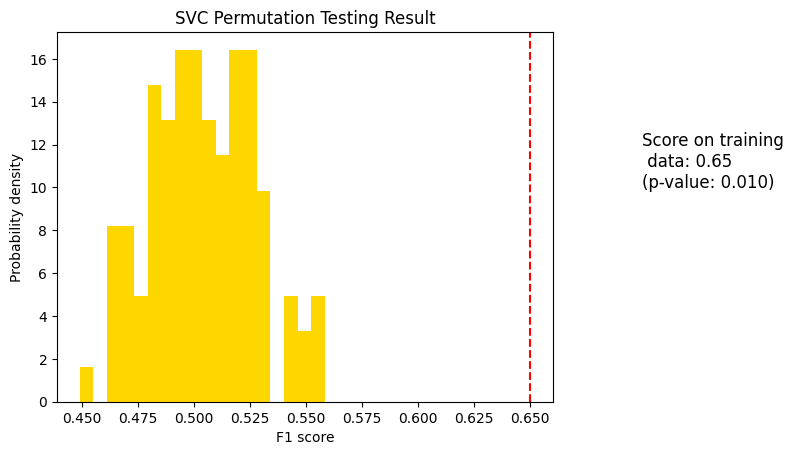

In [79]:
fig, ax = plt.subplots()

ax.hist(perm_score, bins=18, density=True, color = 'gold')
ax.axvline(score, ls="--", color="r")
score_label = (
    f"Score on training\n data: {score:.2f}\n(p-value: {pvlaue:.3f})"
)
ax.text(0.7, 10, score_label, fontsize=12)
ax.set_xlabel("F1 score")
_ = ax.set_ylabel("Probability density")
plt.title("SVC Permutation Testing Result")
plt.savefig("./Results/SVC_significance")

# Ridge Regression

In [80]:
rc = RidgeClassifier(random_state = 42)

In [81]:
#  CV to find the best alpha
alpha_range = 10. ** np.arange(0, 7)

train_scores, valid_scores = validation_curve(rc, X_train_scl, y_train, 
                                              param_name= "alpha",
                                              param_range = alpha_range,
                                              cv=5,
                                              scoring='f1_macro')

In [1]:
valid_scores

NameError: name 'valid_scores' is not defined

In [53]:
tScores = pd.DataFrame(train_scores).stack().reset_index()
tScores.columns = ['Alpha','Fold','Score']
tScores.loc[:,'Type'] = ['Train' for x in range(len(tScores))]

vScores = pd.DataFrame(valid_scores).stack().reset_index()
vScores.columns = ['Alpha','Fold','Score']
vScores.loc[:,'Type'] = ['Validate' for x in range(len(vScores))]

ValCurves = pd.concat([tScores,vScores]).reset_index(drop=True)
ValCurves.head()

,Alpha,Fold,Score,Type
0,0,0,1.0,Train
1,0,1,1.0,Train
2,0,2,1.0,Train
3,0,3,1.0,Train
4,0,4,1.0,Train


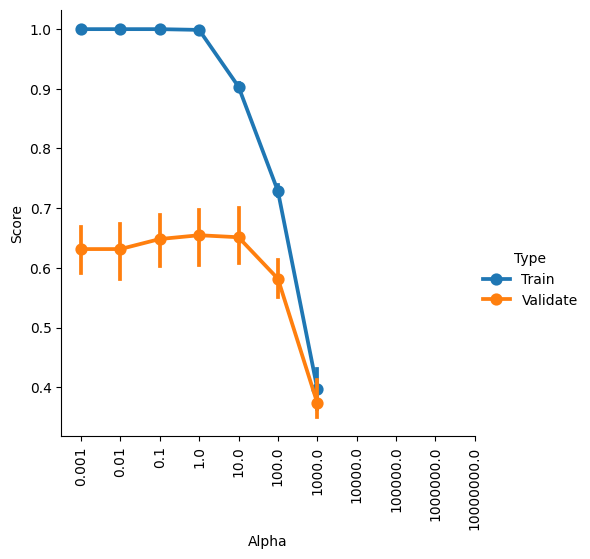

In [54]:
g = sns.catplot(x='Alpha',y='Score',hue='Type',data=ValCurves,kind='point')
plt.xticks(range(11))
g.set_xticklabels(C_range, rotation=90)

In [82]:
grid_rc = GridSearchCV(
    rc,
    {"alpha": alpha_range},
    scoring = "f1_macro",
    cv = 5
)

grid_rc.fit(X_train_scl, y_train)

pd.DataFrame(grid_rc.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.254394,0.092201,0.011142,0.004232,1.0,{'alpha': 1.0},0.548507,0.631696,0.689922,0.664336,0.622879,0.631468,0.047861,4
1,0.163949,0.040881,0.006871,0.003404,10.0,{'alpha': 10.0},0.548507,0.631696,0.689922,0.664336,0.622879,0.631468,0.047861,4
2,0.133176,0.035294,0.005057,0.001602,100.0,{'alpha': 100.0},0.572793,0.648438,0.715402,0.681920,0.622879,0.648286,0.048950,3
3,0.151836,0.043390,0.004374,0.000696,1000.0,{'alpha': 1000.0},0.566667,0.657167,0.724061,0.688005,0.637411,0.654662,0.052868,1
4,0.120135,0.017699,0.008417,0.007571,10000.0,{'alpha': 10000.0},0.587835,0.668344,0.747475,0.637411,0.615357,0.651284,0.054868,2
5,0.256606,0.072717,0.014455,0.006061,100000.0,{'alpha': 100000.0},0.537201,0.597070,0.635417,0.597070,0.542125,0.581776,0.037160,6
6,0.170956,0.080052,0.009313,0.010952,1000000.0,{'alpha': 1000000.0},0.371147,0.351351,0.446023,0.351351,0.347826,0.373540,0.037163,7


In [83]:
print(f"Best Alpha: {grid_rc.best_params_['alpha']}")
print(f"Best F1: {grid_rc.best_score_}")

Best Alpha: 1000.0
Best F1: 0.6546621600541469


In [84]:
rc_best = grid_rc.best_estimator_

rc_best.fit(X_train_scl, y_train)
y_pred = rc_best.predict(X_test_scl)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.71      0.68        82
           1       0.61      0.55      0.58        69

    accuracy                           0.64       151
   macro avg       0.63      0.63      0.63       151
weighted avg       0.63      0.64      0.63       151



In [85]:
metrics.r2_score(y_test, y_pred)

-0.4678331565924354

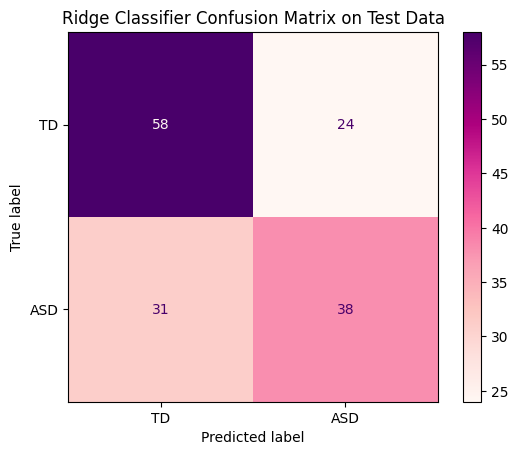

In [90]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels = [0, 1],
    display_labels = ['TD', 'ASD'],
    cmap = 'RdPu'
)

plt.title('Ridge Classifier Confusion Matrix on Test Data')
plt.savefig("./Results/RC_cm")

In [87]:
score, perm_score, pvalue = permutation_test_score(
    rc_best,
    X_train_scl,
    y_train,
    cv = 5,
    n_permutations = 100,
    random_state = 42,
    scoring = 'f1_macro'
)

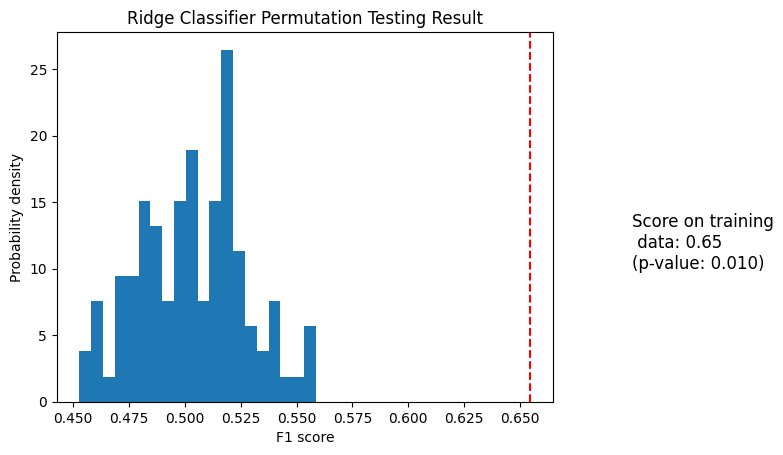

In [88]:
fig, ax = plt.subplots()

ax.hist(perm_score, bins=20, density=True)
ax.axvline(score, ls="--", color="r")
score_label = (
    f"Score on training\n data: {score:.2f}\n(p-value: {pvalue:.3f})"
)
ax.text(0.7, 10, score_label, fontsize=12)
ax.set_xlabel("F1 score")
_ = ax.set_ylabel("Probability density")
plt.title("Ridge Classifier Permutation Testing Result")
plt.savefig("./Results/RC_significance")

# MLP

In [16]:
mlp_clf = MLPClassifier(hidden_layer_sizes = [300,], random_state=42)

In [17]:
param_dict = {
    "activation": ['identity', 'logistic', 'tanh', 'relu'],
    "alpha": 10. ** np.arange(-2, 5)
}

grid_mlp = GridSearchCV(
    mlp_clf,
    param_dict,
    scoring = "f1_macro",
    cv = 5
)

grid_mlp.fit(X_train_scl, y_train)

pd.DataFrame(grid_mlp.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,8.304435,1.185696,0.015524,0.000277,identity,0.01,"{'activation': 'identity', 'alpha': 0.01}",0.560904,0.641642,0.733037,0.699666,0.616240,0.650298,0.060843,6
1,35.722651,0.667441,0.015381,0.000096,identity,0.10,"{'activation': 'identity', 'alpha': 0.1}",0.560904,0.649903,0.732665,0.674797,0.607652,0.645184,0.058419,8
2,35.635632,0.391574,0.016218,0.000763,identity,1.00,"{'activation': 'identity', 'alpha': 1.0}",0.578051,0.658120,0.724522,0.705862,0.598214,0.652954,0.057541,4
3,19.508800,4.127821,0.015357,0.000171,identity,10.00,"{'activation': 'identity', 'alpha': 10.0}",0.600000,0.632414,0.733259,0.563636,0.640443,0.633951,0.056575,13
4,9.740728,1.429049,0.016018,0.001417,identity,100.00,"{'activation': 'identity', 'alpha': 100.0}",0.560904,0.546853,0.674797,0.641642,0.590957,0.603030,0.048410,17
5,20.233676,0.376180,0.015380,0.000153,identity,1000.00,"{'activation': 'identity', 'alpha': 1000.0}",0.349462,0.351351,0.351351,0.351351,0.347826,0.350269,0.001424,20
6,28.460654,1.040211,0.019290,0.007800,identity,10000.00,"{'activation': 'identity', 'alpha': 10000.0}",0.349462,0.351351,0.351351,0.351351,0.347826,0.350269,0.001424,20
7,16.325410,0.718057,0.021211,0.010162,logistic,0.01,"{'activation': 'logistic', 'alpha': 0.01}",0.536905,0.633231,0.733037,0.707826,0.613986,0.644997,0.069975,9
8,29.729742,3.826428,0.015754,0.000203,logistic,0.10,"{'activation': 'logistic', 'alpha': 0.1}",0.577473,0.449954,0.724828,0.597070,0.559342,0.581733,0.087860,19
9,11.370965,2.484863,0.024945,0.012368,logistic,1.00,"{'activation': 'logistic', 'alpha': 1.0}",0.578051,0.616240,0.732665,0.663300,0.622879,0.642627,0.052518,10


In [19]:
print(grid_mlp.best_score_)
print(grid_mlp.best_estimator_)

0.662232738706534
MLPClassifier(activation='tanh', alpha=np.float64(10.0),
              hidden_layer_sizes=[300], random_state=42)


In [20]:
pd.DataFrame(grid_mlp.cv_results_).to_csv("./Results/MLP_GridCV.csv", index = False)

In [21]:
mlp_best = grid_mlp.best_estimator_

mlp_best.fit(X_train_scl, y_train)
y_pred = mlp_best.predict(X_test_scl)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.79      0.66        82
           1       0.54      0.29      0.38        69

    accuracy                           0.56       151
   macro avg       0.56      0.54      0.52       151
weighted avg       0.56      0.56      0.53       151



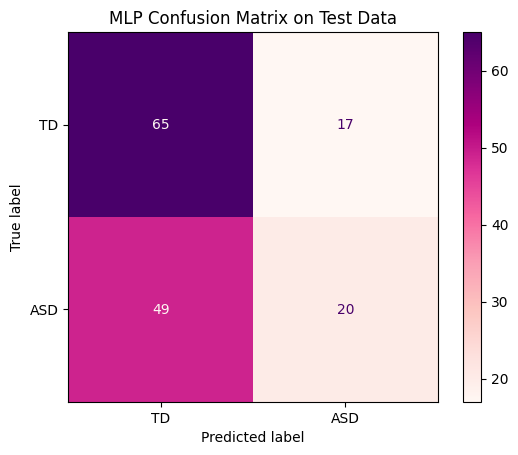

In [22]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels = [0, 1],
    display_labels = ['TD', 'ASD'],
    cmap = 'RdPu'
)

plt.title('MLP Confusion Matrix on Test Data')
plt.savefig("./Results/MLP_cm")

In [ ]:
score, perm_score, pvalue = permutation_test_score(
    mlp_best,
    X_train_scl,
    y_train,
    cv = 5,
    n_permutations = 100,
    random_state = 42,
    scoring = 'f1'
)

In [ ]:
import json
result_dict = {
    "score": score,
    "perm_score": perm_score,
    "pvalue": pvalue
}

with open("./Results/MLP_perm", "w") as fp:
    json.dump(result_dict, fp, indent = 4)

In [ ]:
fig, ax = plt.subplots()

ax.hist(perm_score, bins=20, density=True, color = 'plum')
ax.axvline(score, ls="--", color="r")
score_label = (
    f"Score on training\n data: {score:.2f}\n(p-value: {pvalue:.3f})"
)
ax.text(0.7, 10, score_label, fontsize=12)
ax.set_xlabel("F1 score")
_ = ax.set_ylabel("Probability density")
plt.title("MLP Permutation Testing Result")
plt.savefig("./Results/MLP_significance")